# Bài giảng 2: Data Preparation trong Tài chính
---
Chào mừng bạn đến với học phần chuyên sâu nhất, nhưng cũng quan trọng nhất, kéo dài 3 tuần trong chương trình Big Data Analytics for Finance. Data Preparation (Chuẩn bị dữ liệu) là buồng máy của tài chính định lượng. Thậm chí những mô hình Deep Learning tinh vi nhất cũng sẽ thất bại thảm hại nếu được cung cấp dữ liệu bị thiên lệch, chưa được scale, hoặc nhiều nhiễu. Như câu ngạn ngữ đã nói: **Garbage In, Garbage Out!**

Trong ba tuần tiếp theo, chúng ta sẽ làm chủ:
1. **Tuần 3:** Advanced Data Cleaning (Xử lý Missing Data và Anomaly Detection trong không gian đa chiều)
2. **Tuần 4:** Data Transformation (Feature Scaling, Encoding, và Imbalanced Learning cho Fraud Detection)
3. **Tuần 5:** Feature Selection (Trích xuất tín hiệu Alpha sử dụng các phương pháp Filter, Wrapper, và Embedded)


## Phần 1: Advanced Data Cleaning (Tuần 3)
---
### 1.1 Mô phỏng một tập dữ liệu Tài chính thực tế
Để minh họa các kỹ thuật này, trước tiên chúng ta sẽ tạo ra một tập dữ liệu tổng hợp (synthetic) phức tạp gồm 10,000 dòng. Tập dữ liệu này bắt chước hành vi của một danh mục đa tài sản (multi-asset portfolio), hoàn chỉnh với các chỉ số kinh tế vĩ mô, các đợt biến động đột ngột (volatility spikes), và dữ liệu bị thiếu có cấu trúc.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, OneHotEncoder
import warnings
warnings.filterwarnings('ignore')

# Cài đặt tham số thẩm mỹ cho biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Tạo 10,000 dòng dữ liệu tài chính giả lập
np.random.seed(42)
dates = pd.date_range(start='2000-01-01', periods=10000, freq='D')

# Các tài sản có tương quan
market_factor = np.random.randn(10000).cumsum()
stock_a = 100 + 1.2 * market_factor + np.random.randn(10000) * 5
stock_b = 50 + 0.8 * market_factor + np.random.randn(10000) * 10
volume = np.abs(np.random.normal(5000, 2000, 10000))
pe_ratio = np.random.uniform(5, 50, 10000)
sector = np.random.choice(['Tech', 'Finance', 'Energy', 'Healthcare', 'Consumer'], 10000)
default_status = np.random.choice([0, 1], p=[0.95, 0.05], size=10000) # Target bị Imbalanced

df = pd.DataFrame({
    'Date': dates,
    'Stock_A': stock_a,
    'Stock_B': stock_b,
    'Volume': volume,
    'PE_Ratio': pe_ratio,
    'Sector': sector,
    'Default': default_status
})

print(f"Dataset Shape: {df.shape}")
display(df.head(50))
display(df.describe(include='all'))


Dataset Shape: (10000, 7)


,Date,Stock_A,Stock_B,Volume,PE_Ratio,Sector,Default
0,2000-01-01,97.203583,53.880234,1038.856065,42.427815,Energy,0
1,2000-01-02,98.902643,53.119996,2890.028706,20.544549,Finance,0
2,2000-01-03,98.220461,41.439712,3825.943187,36.741641,Healthcare,0
3,2000-01-04,103.587092,57.819177,5299.337822,7.277116,Healthcare,0
4,2000-01-05,108.739911,36.935185,7048.324653,25.880829,Finance,1
5,2000-01-06,98.617843,45.106859,6388.271887,47.199977,Consumer,0
6,2000-01-07,109.372211,32.921194,2641.350403,17.334025,Healthcare,0
7,2000-01-08,101.380670,69.112286,4256.575476,7.248686,Healthcare,0
8,2000-01-09,100.487525,50.834946,5152.751177,31.232525,Healthcare,0
9,2000-01-10,109.469706,75.253329,4475.585751,20.979489,Energy,0


,Date,Stock_A,Stock_B,Volume,PE_Ratio,Sector,Default
count,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000,10000.000000
unique,NaN,NaN,NaN,NaN,NaN,5,NaN
top,NaN,NaN,NaN,NaN,NaN,Consumer,NaN
freq,NaN,NaN,NaN,NaN,NaN,2034,NaN
mean,2013-09-08 12:00:00,121.618079,64.242311,4994.621817,27.583940,NaN,0.051200
min,2000-01-01 00:00:00,14.510759,-20.830487,12.853148,5.000379,NaN,0.000000
25%,2006-11-04 18:00:00,76.125011,32.273070,3611.048503,16.639051,NaN,0.000000
50%,2013-09-08 12:00:00,106.916800,56.688706,4979.235507,27.604181,NaN,0.000000
75%,2020-07-13 06:00:00,182.351822,100.771491,6358.060905,38.796450,NaN,0.000000
max,2027-05-18 00:00:00,242.879167,160.801915,12455.666690,49.997286,NaN,1.000000


### 1.2 Missing Data: Phân tích và Trực quan hóa
Missing data (dữ liệu bị thiếu) trong tài chính hiếm khi là MCAR (Missing Completely At Random). Nó thường là MAR (Missing At Random) do các ngày nghỉ lễ, hoặc MNAR (Missing Not At Random) khi một tài sản thanh khoản kém (illiquid) không thể xác định giá.

Hãy chèn một số missing values và trực quan hóa chúng bằng ma trận dữ liệu thiếu.


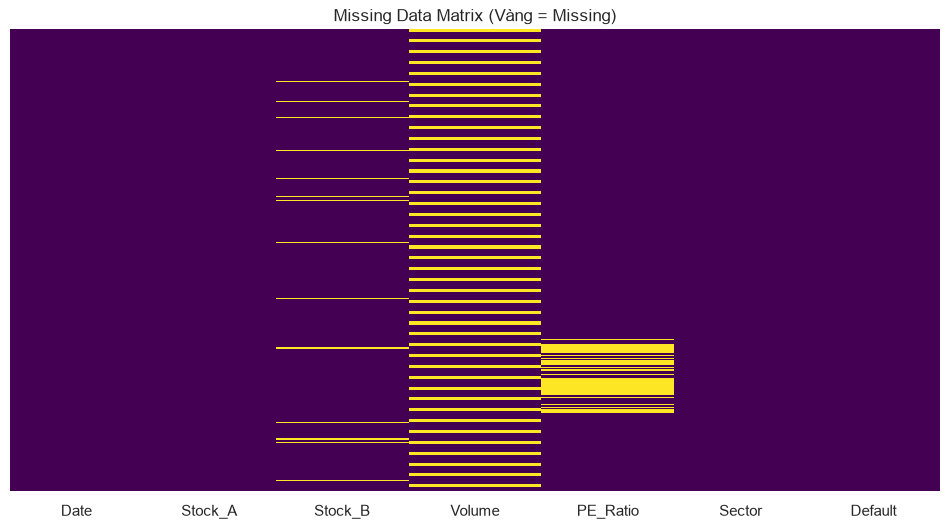

Tỷ lệ missing data trên mỗi cột:
Date         0.00
Stock_A      0.00
Stock_B      5.00
Volume      28.58
PE_Ratio     9.44
Sector       0.00
Default      0.00
dtype: float64


In [2]:
# Chèn dữ liệu bị thiếu
# MAR: Thiếu Volume vào các ngày cuối tuần
df.loc[df['Date'].dt.dayofweek >= 5, 'Volume'] = np.nan

# MNAR: Thiếu PE_Ratio khi Stock_A giảm xuống dưới 50
df.loc[df['Stock_A'] < 50, 'PE_Ratio'] = np.nan

# Random MCAR
random_indices = np.random.choice(df.index, size=500, replace=False)
df.loc[random_indices, 'Stock_B'] = np.nan

# Trực quan hóa Missing Data
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Data Matrix (Vàng = Missing)")
plt.show()

print("Tỷ lệ missing data trên mỗi cột:")
print((df.isnull().sum() / len(df)) * 100)


### 1.3 Các chiến lược Imputation nâng cao
Đối với chuỗi thời gian tài chính, phương pháp Imputation bằng Mean/Median đơn giản sẽ phá hủy cấu trúc thời gian. Chúng ta phải sử dụng Time-Series Interpolation.

* **Linear Interpolation:** Giả định một đường thẳng giữa các điểm bị thiếu.
* **Spline Interpolation:** Khớp một đường cong mượt (polynomial) qua các điểm.


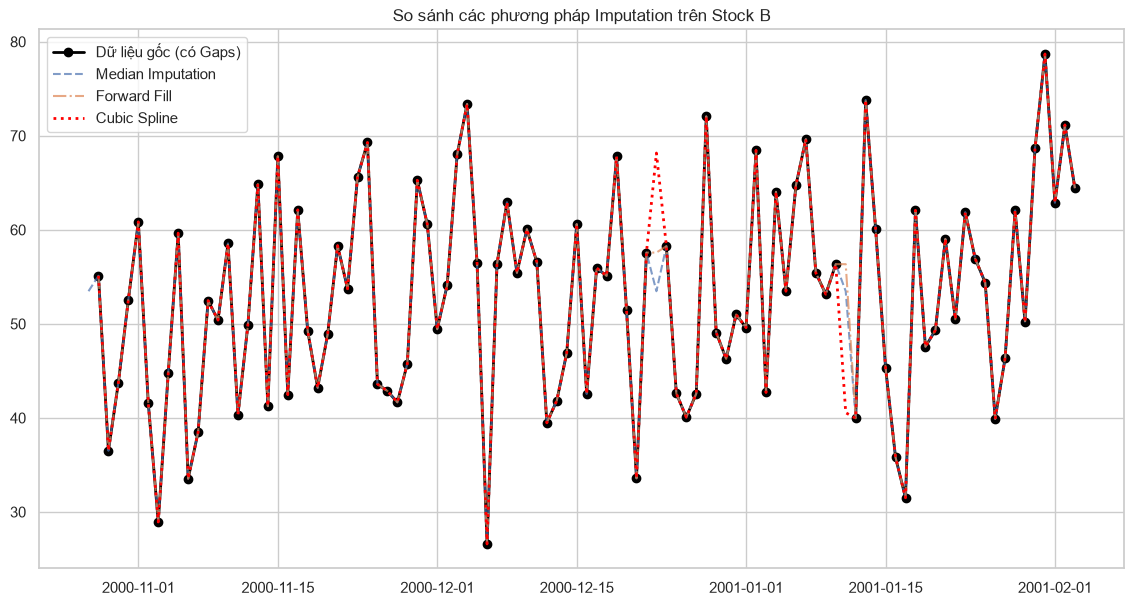

In [3]:
# Phóng to vào một cửa sổ cụ thể để xem hiệu ứng
window = df.iloc[300:400].copy()

# Median đơn giản
window['Stock_B_Median'] = window['Stock_B'].fillna(window['Stock_B'].median())
# Forward Fill
window['Stock_B_FFill'] = window['Stock_B'].fillna(method='ffill')
# Spline Interpolation
window['Stock_B_Spline'] = window['Stock_B'].interpolate(method='spline', order=3)

plt.figure(figsize=(14, 7))
plt.plot(window['Date'], window['Stock_B'], marker='o', label='Dữ liệu gốc (có Gaps)', color='black', linewidth=2)
plt.plot(window['Date'], window['Stock_B_Median'], linestyle='--', label='Median Imputation', alpha=0.7)
plt.plot(window['Date'], window['Stock_B_FFill'], linestyle='-.', label='Forward Fill', alpha=0.7)
plt.plot(window['Date'], window['Stock_B_Spline'], linestyle=':', label='Cubic Spline', linewidth=2, color='red')

plt.title("So sánh các phương pháp Imputation trên Stock B")
plt.legend()
plt.show()

# Áp dụng phương pháp tốt nhất cho toàn bộ tập dữ liệu
df['Stock_B'] = df['Stock_B'].interpolate(method='linear')
df['Volume'] = df['Volume'].fillna(method='ffill')
df['PE_Ratio'] = df['PE_Ratio'].fillna(df['PE_Ratio'].median())


### 1.4 Multivariate Outlier Detection
Mặc dù Z-Score và IQR rất tuyệt vời cho các biến đơn lẻ (Univariate), nhưng các gian lận tài chính hoặc dị thường (anomalies) thường xuất hiện trong không gian đa chiều (multivariate). Một lệnh giao dịch có thể có Price bình thường và Volume bình thường một cách độc lập, nhưng *sự kết hợp* của Price và Volume đó có thể cực kỳ bất thường!

#### Isolation Forest
Isolation Forest là một thuật toán học không giám sát (unsupervised), giúp cô lập các điểm bất thường (anomalies) thay vì lập hồ sơ các điểm bình thường. Nó xây dựng các Random Trees; các Outliers, vì số lượng ít và khác biệt, cuối cùng sẽ nằm gần gốc của cây hơn (độ dài đường đi ngắn hơn).


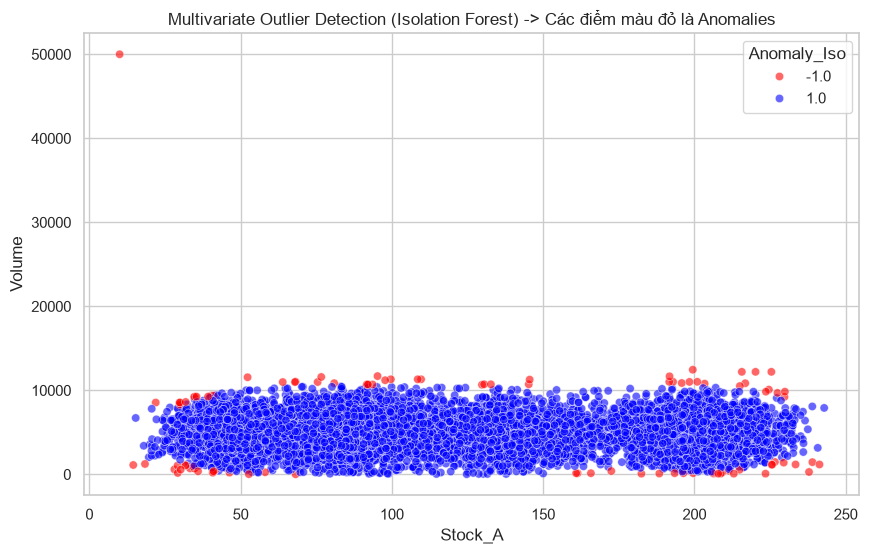

In [4]:
from sklearn.ensemble import IsolationForest

# Đưa vào một vài Multivariate Outliers tổng hợp (các giao dịch Flash Crash / Fat Finger)
df.loc[1000, ['Stock_A', 'Volume']] = [10, 50000]
df.loc[5000, ['Stock_A', 'Volume']] = [150, 100]

# Fit Isolation Forest trên Stock_A và Volume
X_outlier = df[['Stock_A', 'Volume']].dropna()
iso_forest = IsolationForest(contamination=0.01, random_state=42)
df.loc[X_outlier.index, 'Anomaly_Iso'] = iso_forest.fit_predict(X_outlier)

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Stock_A', y='Volume', hue='Anomaly_Iso', palette={1: 'blue', -1: 'red'}, alpha=0.6)
plt.title("Multivariate Outlier Detection (Isolation Forest) -> Các điểm màu đỏ là Anomalies")
plt.show()


## Phần 2: Data Transformation (Tuần 4)
---
### 2.1 Toán học của Feature Scaling
Các thuật toán Machine Learning (đặc biệt là các thuật toán dựa trên Gradient Descent như Neural Nets, hoặc dựa trên khoảng cách như KNN) mặc định coi tất cả các Features là bình đẳng. Nếu Volume lên tới hàng triệu và Price chỉ ở mức hàng chục, Volume sẽ thống trị gradient!

Hãy so sánh ba bộ Scaler một cách trực quan trên dữ liệu `Volume` bị lệch rất lớn.


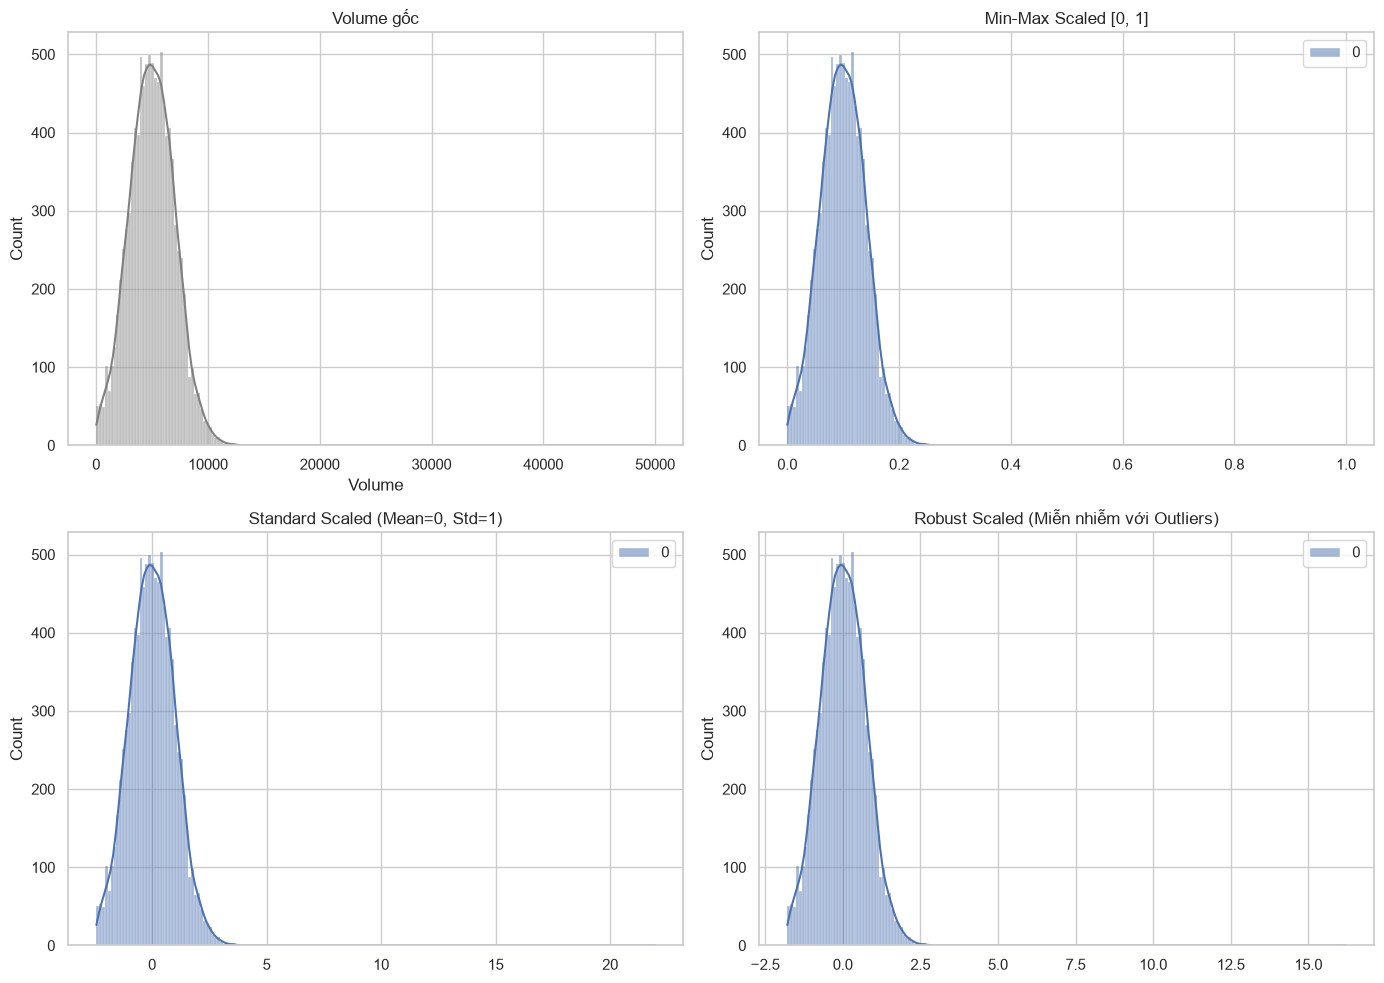

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df['Volume'], kde=True, ax=axes[0, 0], color='gray').set_title("Volume gốc")

# 1. Min-Max Scaler
mm_scaler = MinMaxScaler()
vol_mm = mm_scaler.fit_transform(df[['Volume']])
sns.histplot(vol_mm, kde=True, ax=axes[0, 1], color='green').set_title("Min-Max Scaled [0, 1]")

# 2. Standard Scaler
std_scaler = StandardScaler()
vol_std = std_scaler.fit_transform(df[['Volume']])
sns.histplot(vol_std, kde=True, ax=axes[1, 0], color='blue').set_title("Standard Scaled (Mean=0, Std=1)")

# 3. Robust Scaler (Sử dụng Median và IQR, miễn nhiễm với Outliers)
rob_scaler = RobustScaler()
vol_rob = rob_scaler.fit_transform(df[['Volume']])
sns.histplot(vol_rob, kde=True, ax=axes[1, 1], color='red').set_title("Robust Scaled (Miễn nhiễm với Outliers)")

plt.tight_layout()
plt.show()


### 2.2 Các chiến lược Encoding
* **One-Hot Encoding:** Tạo các cột nhị phân (binary columns). Tốt nhất cho các đặc trưng có số lượng danh mục thấp (low cardinality).
* **Target Encoding:** Thay thế một giá trị category bằng trung bình của biến target cho category đó. Cực kỳ mạnh mẽ đối với các high-cardinality features như Stock Tickers, Mã Zip, hoặc Sector Codes khi dự đoán Rủi ro Vỡ nợ (Default Risk).


In [6]:
# One-Hot Encoding
df_ohe = pd.get_dummies(df, columns=['Sector'])
print("One-Hot Encoded Shape:", df_ohe.shape)
display(df_ohe.head(30))

# Target Encoding (Triển khai thủ công để minh họa)
# Chúng ta thay thế 'Sector' bằng tỷ lệ default trong lịch sử của sector đó
target_means = df.groupby('Sector')['Default'].mean()
print("\nTarget Encoding Mapping (Tỷ lệ Default theo Sector):")
display(pd.DataFrame(target_means))

df['Sector_Target_Encoded'] = df['Sector'].map(target_means)


One-Hot Encoded Shape: (10000, 12)


,Date,Stock_A,Stock_B,Volume,PE_Ratio,Default,Anomaly_Iso,Sector_Consumer,Sector_Energy,Sector_Finance,Sector_Healthcare,Sector_Tech
0,2000-01-01,97.203583,53.880234,NaN,42.427815,0,NaN,False,True,False,False,False
1,2000-01-02,98.902643,53.119996,NaN,20.544549,0,NaN,False,False,True,False,False
2,2000-01-03,98.220461,55.469586,3825.943187,36.741641,0,1.0,False,False,False,True,False
3,2000-01-04,103.587092,57.819177,5299.337822,7.277116,0,1.0,False,False,False,True,False
4,2000-01-05,108.739911,36.935185,7048.324653,25.880829,1,1.0,False,False,True,False,False
5,2000-01-06,98.617843,45.106859,6388.271887,47.199977,0,1.0,True,False,False,False,False
6,2000-01-07,109.372211,32.921194,2641.350403,17.334025,0,1.0,False,False,False,True,False
7,2000-01-08,101.380670,69.112286,2641.350403,7.248686,0,1.0,False,False,False,True,False
8,2000-01-09,100.487525,50.834946,2641.350403,31.232525,0,1.0,False,False,False,True,False
9,2000-01-10,109.469706,75.253329,4475.585751,20.979489,0,1.0,False,True,False,False,False



Target Encoding Mapping (Tỷ lệ Default theo Sector):


,Default
Sector,
Consumer,0.042281
Energy,0.047789
Finance,0.053774
Healthcare,0.060062
Tech,0.052372


### 2.3 Xử lý Imbalanced Data (Nghịch lý độ chính xác - The Accuracy Paradox)
Trong tập dữ liệu của chúng ta, chỉ ~5% số quan sát là Defaults (`Default == 1`). Một mô hình ngây thơ dự đoán "0" mọi lúc sẽ đạt được độ chính xác (Accuracy) 95% nhưng hoàn toàn vô dụng đối với việc quản trị rủi ro!

Chúng ta sẽ sử dụng thuật toán **SMOTE (Synthetic Minority Over-sampling Technique)** để tạo ra các điểm dữ liệu tổng hợp của class thiểu số trong không gian Features.

Hãy sử dụng PCA (Principal Component Analysis) để nén các Features của chúng ta xuống không gian 2D để thực sự *nhìn thấy* sự mất cân bằng, và sau đó xem SMOTE hoạt động như thế nào.


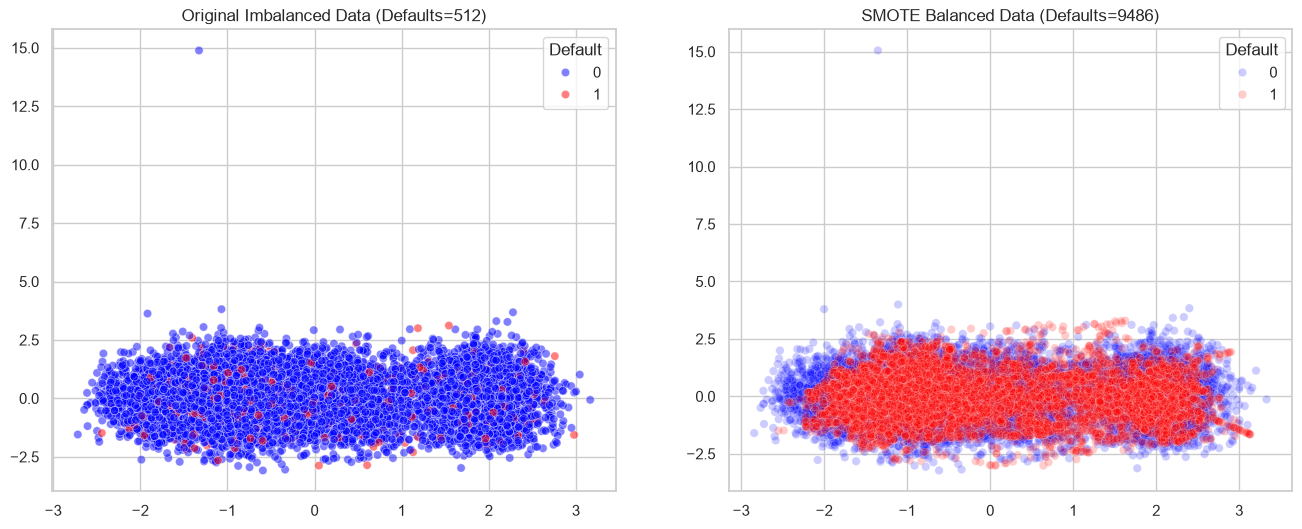

In [7]:
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA

# Chuẩn bị Features
features = ['Stock_A', 'Stock_B', 'Volume', 'PE_Ratio', 'Sector_Target_Encoded']
X = df[features].dropna()
y = df.loc[X.index, 'Default']

# Giảm xuống 2D để trực quan hóa
pca = PCA(n_components=2)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X))

# Áp dụng SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
X_resampled_pca = pca.transform(StandardScaler().fit_transform(X_resampled))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Vẽ biểu đồ gốc bị Imbalanced
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, alpha=0.5, ax=axes[0], palette=['blue', 'red'])
axes[0].set_title(f"Original Imbalanced Data (Defaults={sum(y==1)})")

# Vẽ biểu đồ đã được cân bằng bằng SMOTE
sns.scatterplot(x=X_resampled_pca[:, 0], y=X_resampled_pca[:, 1], hue=y_resampled, alpha=0.2, ax=axes[1], palette=['blue', 'red'])
axes[1].set_title(f"SMOTE Balanced Data (Defaults={sum(y_resampled==1)})")

plt.show()


## Phần 3: Feature Selection (Tuần 5)
---
Nhiều dữ liệu hơn không phải lúc nào cũng tốt hơn. Việc đưa các Features nhiễu, không liên quan vào mô hình sẽ khiến nó ghi nhớ nhiễu (Overfitting). Feature Selection sẽ cô lập các tín hiệu alpha thực sự.


### 3.1 Filter Methods: Pearson Correlation & Mutual Information
Filter methods đánh giá các Features độc lập với bất kỳ mô hình nào.
* **Correlation:** Mối quan hệ tuyến tính.
* **Mutual Information:** Nắm bắt các phụ thuộc phi tuyến tính (non-linear) dựa trên lý thuyết thông tin.


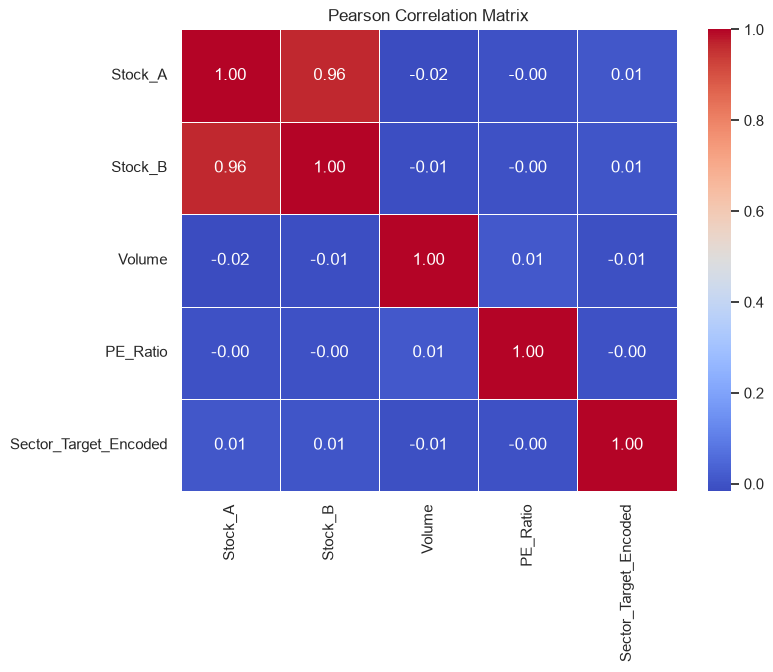

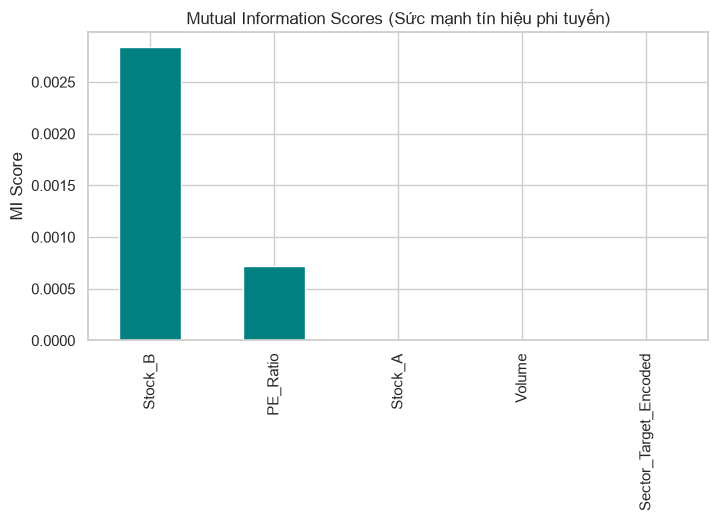

In [8]:
from sklearn.feature_selection import mutual_info_classif

# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Pearson Correlation Matrix")
plt.show()

# Mutual Information
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
mi_series.plot(kind='bar', color='teal')
plt.title("Mutual Information Scores (Sức mạnh tín hiệu phi tuyến)")
plt.ylabel("MI Score")
plt.show()


### 3.2 Wrapper Methods: Recursive Feature Elimination (RFE)
RFE huấn luyện một mô hình, loại bỏ Feature yếu nhất, và huấn luyện lại. RFECV bổ sung Cross-Validation để tự động tìm ra số lượng Features tối ưu!


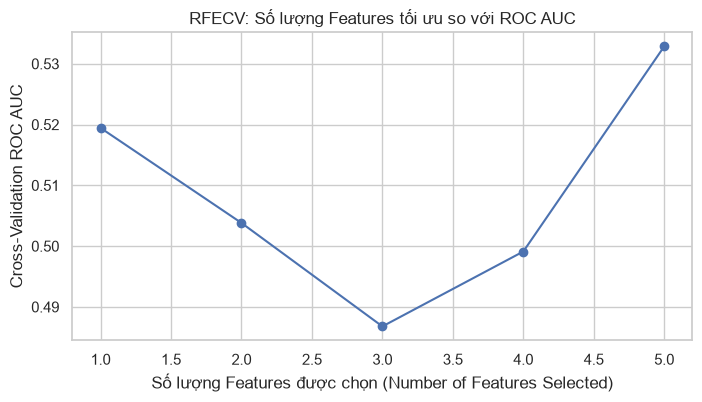

Selected Features: ['Stock_A', 'Stock_B', 'Volume', 'PE_Ratio', 'Sector_Target_Encoded']


In [9]:
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier

# Cảnh báo: Chạy RFECV với RandomForest trên 10k dòng tính toán rất tốn kém. 
# Chúng ta sử dụng một tập con (subset) và ít estimators hơn để minh họa tốc độ.
rf = RandomForestClassifier(n_estimators=20, max_depth=5, random_state=42, n_jobs=-1)
selector = RFECV(estimator=rf, step=1, cv=3, scoring='roc_auc')

selector = selector.fit(X.iloc[:2000], y.iloc[:2000])

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(selector.cv_results_['mean_test_score']) + 1), selector.cv_results_['mean_test_score'], marker='o')
plt.title("RFECV: Số lượng Features tối ưu so với ROC AUC")
plt.xlabel("Số lượng Features được chọn (Number of Features Selected)")
plt.ylabel("Cross-Validation ROC AUC")
plt.show()

print("Selected Features:", X.columns[selector.support_].tolist())


### 3.3 Embedded Methods: Feature Importances
Các mô hình dạng cây (Tree-based models) tính toán mức độ mà mỗi feature đóng góp vào việc giảm Gini Impurity trên tất cả các nút (nodes) trong toàn bộ khu rừng (forest).


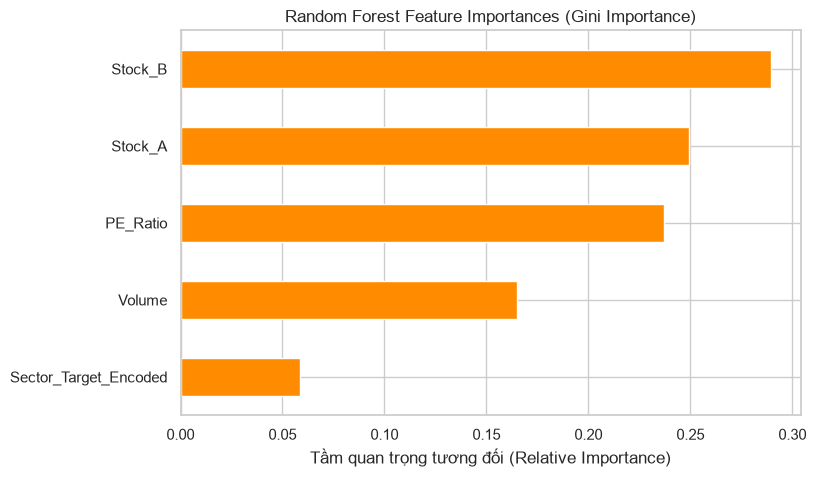

In [10]:
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='darkorange')
plt.title("Random Forest Feature Importances (Gini Importance)")
plt.xlabel("Tầm quan trọng tương đối (Relative Importance)")
plt.show()


---
## Phần 4: Bài tập tổng hợp (Case Study)
---
> **Hướng dẫn:** Bạn là một Quantitative Analyst tại một ngân hàng lớn. Bạn vừa được giao một tập dữ liệu thô `credit_risk_raw.csv`. Quản lý của bạn kỳ vọng sẽ nhận được một tập dữ liệu nguyên sơ, đã được transformed hoàn hảo để sẵn sàng cho quá trình modeling vào cuối ngày. Hãy làm theo các bước dưới đây. BÀI TẬP NÀY KHÔNG CÓ CODE GIẢI MẪU.

### Thử thách 1: Data Cleaning
1. Tải tập dữ liệu. Xác định những cột nào có Missing Data.
2. Cột `Employment_Length` có dữ liệu bị thiếu (MAR). Impute nó bằng Mode.
3. Cột `Annual_Income` bị lệch phải (right-skewed) nặng. Phát hiện Outliers bằng phương pháp IQR và áp dụng Winsorization ở bách phân vị (percentile) thứ 95.

### YOUR CODE HERE ###


In [11]:
# YOUR CODE HERE


### Thử thách 2: Transformation & Class Imbalance
1. Biến target `Loan_Status` bị Imbalanced. Tỷ lệ hiện tại giữa Default và Non-Default là bao nhiêu?
2. Áp dụng Target Encoding cho biến phân loại `Zip_Code`.
3. Scale tất cả các biến số (numerical features) bằng cách sử dụng `RobustScaler`.
4. Áp dụng SMOTE để cân bằng tập dữ liệu huấn luyện. Vẽ biểu đồ phân phối mới.

### YOUR CODE HERE ###


In [12]:
# YOUR CODE HERE


### Thử thách 3: Feature Selection Pipeline
1. Tính toán Pearson Correlation matrix của tập dữ liệu đã làm sạch. Có Features nào tương quan cao với nhau (multicollinearity) không? Nếu có, hãy loại bỏ một trong số chúng.
2. Chạy một `RandomForestClassifier` trên tập dữ liệu đã được cân bằng bằng SMOTE.
3. Trích xuất và vẽ biểu đồ Feature Importances. Nêu kết luận của bạn về 3 yếu tố thúc đẩy credit default lớn nhất.

### YOUR CODE HERE ###


In [13]:
# YOUR CODE HERE
